2026-02-01 20:30:07.274941: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-01 20:30:07.894486: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-01 20:30:10.535270: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Loaded 223,732 rows
Removed 45,582 stale quotes. Remaining: 174,322
Median bid-ask spread: 4.33
Train: 139,457  |  Test: 34,865


/home/krish-tandel/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-01 20:30:43.910709: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 400)            │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 400)            │         1,600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 400)            │         1,600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 400)            │         1,600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           802 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,202 (1.26 MB)

 Trainable params: 326,802 (1.25 MB)

 Non-trainable params: 2,400 (9.38 KB)

Epoch 1/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - loss: 0.0670 - val_loss: 0.0130 - learning_rate: 0.0010
Epoch 2/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - loss: 0.0035 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0030 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 4/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0028 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 5/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0030 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 6/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0025 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 7/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0024 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 8/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0023 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 9/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0021 - val_loss: 0.0025 - learning_rate

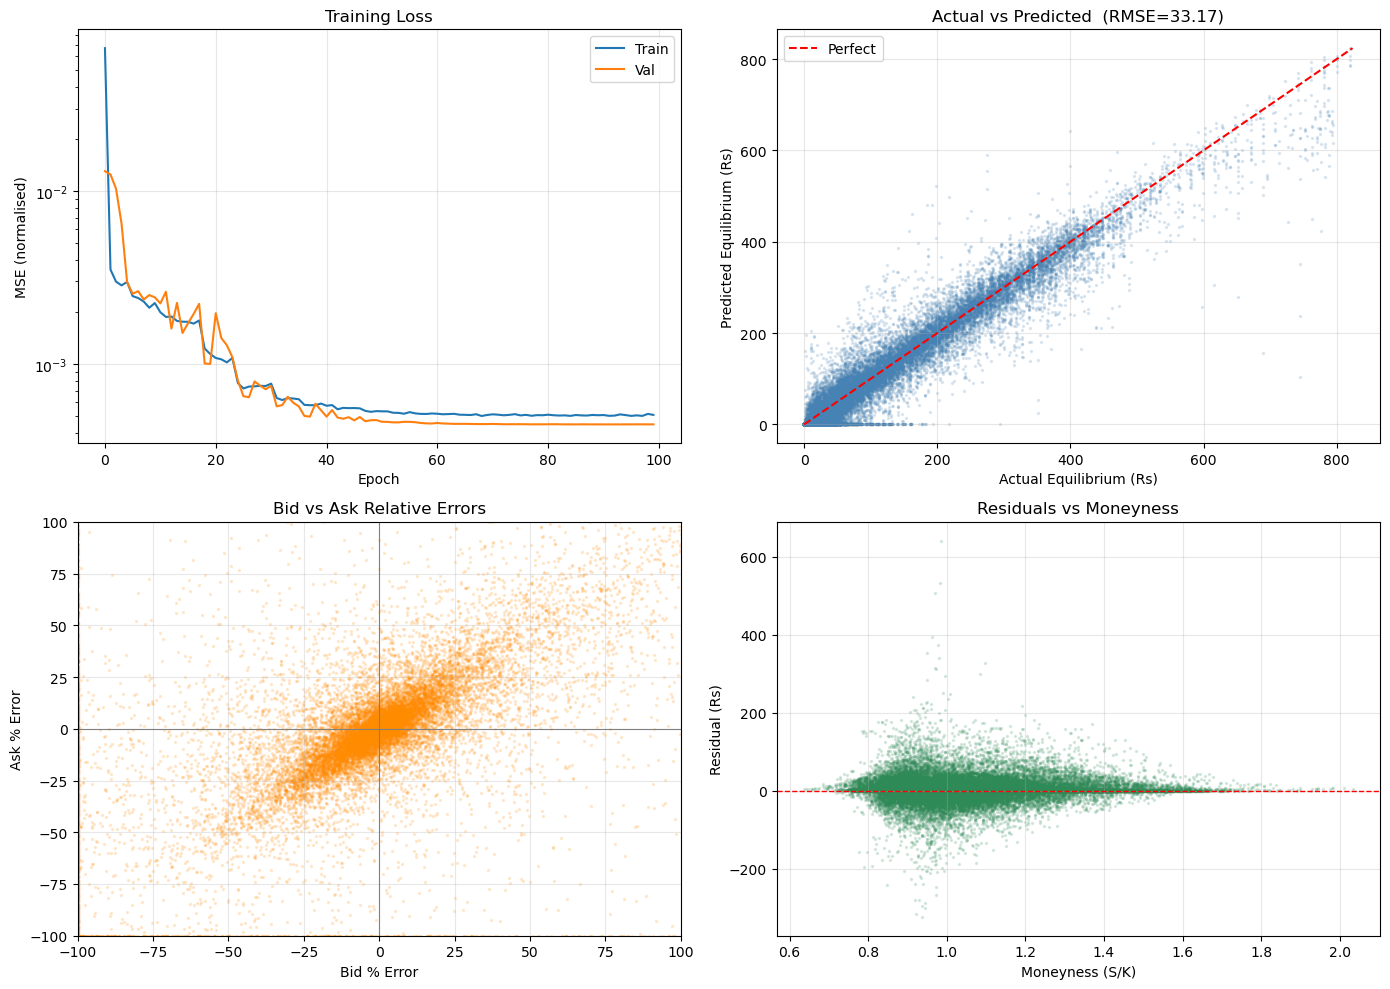

Saved model and scaler.


In [1]:
# MLP2 – Asian Paints Option Pricing (Bid / Ask Multi-Task)

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Load data

try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()

raw = pd.read_excel(os.path.join(base_dir, "ASIANPAINT_Dataset.xlsx"), sheet_name=None)

all_frames = []
for name, sheet in raw.items():
    sheet = sheet.copy()
    sheet["is_call"] = 1 if name.startswith("CE") else 0
    all_frames.append(sheet)

data = pd.concat(all_frames, ignore_index=True)
data["Date"] = pd.to_datetime(data["Date"])
print(f"Loaded {len(data):,} rows")


# Clean

data = data[data["t"] > 0].copy()

S = data["underlying_value"]
K = data["strike_price"]
intrinsic_val = np.where(data["is_call"] == 1, (S - K).clip(lower=0), (K - S).clip(lower=0))
n_before = len(data)
data = data[data["close"] >= intrinsic_val - 0.05].copy()
print(f"Removed {n_before - len(data):,} stale quotes. Remaining: {len(data):,}")


# Synthesise bid / ask

np.random.seed(42)

m_raw = data["underlying_value"] / data["strike_price"]
gamma_component = 0.02 / ((m_raw - 1.0) ** 2 + 0.01)
half_spread = 0.50 + 0.005 * data["close"] + gamma_component
noise = np.random.uniform(0.0, 0.1, size=len(data))

data["bid"] = (data["close"] - half_spread - noise).clip(lower=0.05)
data["ask"] = data["close"] + half_spread + noise
print(f"Median bid-ask spread: {(data['ask'] - data['bid']).median():.2f}")

# Features

data["vol_annual"]  = data["sigma"] * np.sqrt(252)
data["T"]           = data["t"] / 365.0
data["m"]           = data["underlying_value"] / data["strike_price"]
data["vol_sqrt_T"]  = data["vol_annual"] * np.sqrt(data["T"])
data["bid_norm"]    = data["bid"]  / data["strike_price"]
data["ask_norm"]    = data["ask"]  / data["strike_price"]

feat_cols = ["m", "T", "r", "vol_annual", "vol_sqrt_T", "is_call"]
X = data[feat_cols].values
y = data[["bid_norm", "ask_norm"]].values
K_vals = data["strike_price"].values


# Split & scale

idx = np.arange(len(X))
X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X, y, idx, test_size=0.2, random_state=42
)

sc = StandardScaler()
X_tr = sc.fit_transform(X_tr)
X_te = sc.transform(X_te)
print(f"Train: {len(X_tr):,}  |  Test: {len(X_te):,}")

# Model

net = Sequential([
    Dense(400, input_shape=(X_tr.shape[1],), kernel_initializer="glorot_uniform"),
    LeakyReLU(0.01),
    BatchNormalization(),
    Dense(400, kernel_initializer="glorot_uniform"),
    LeakyReLU(0.01),
    BatchNormalization(),
    Dense(400, kernel_initializer="glorot_uniform"),
    LeakyReLU(0.01),
    BatchNormalization(),
    Dense(2, activation="relu")   # bid, ask
])
net.compile(optimizer=Adam(1e-3), loss="mse")
net.summary()

# Train

cbs = [
    ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, verbose=1),
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)
]

history = net.fit(X_tr, y_tr, validation_split=0.125, epochs=100,
                  batch_size=1024, callbacks=cbs, verbose=1)

# Evaluate

pred_norm  = net.predict(X_te)
strikes_te = K_vals[idx_te].reshape(-1, 1)

pred_bid = pred_norm[:, 0:1] * strikes_te
pred_ask = pred_norm[:, 1:2] * strikes_te
true_bid = y_te[:, 0:1] * strikes_te
true_ask = y_te[:, 1:2] * strikes_te

pred_eq = (pred_bid + pred_ask) / 2.0
true_eq = (true_bid + true_ask) / 2.0

rmse_eq = np.sqrt(mean_squared_error(true_eq, pred_eq))
mae_eq  = mean_absolute_error(true_eq, pred_eq)
r2_eq   = r2_score(true_eq, pred_eq)

print(f"\n{'='*40}")
print(f"  Equilibrium RMSE : {rmse_eq:.4f}")
print(f"  Equilibrium MAE  : {mae_eq:.4f}")
print(f"  Equilibrium R²   : {r2_eq:.6f}")

for tag, yt, yp in [("Bid", true_bid, pred_bid), ("Ask", true_ask, pred_ask)]:
    r = np.sqrt(mean_squared_error(yt, yp))
    print(f"  {tag} RMSE : {r:.4f}  R²: {r2_score(yt, yp):.6f}")
print(f"{'='*40}")

# call / put breakdown

call_put = data["is_call"].values[idx_te]
for label, flag in [("Call", 1), ("Put", 0)]:
    mask = call_put == flag
    r = np.sqrt(mean_squared_error(true_eq[mask], pred_eq[mask]))
    print(f"  {label} — RMSE: {r:.4f}  R²: {r2_score(true_eq[mask], pred_eq[mask]):.6f}")

# moneyness buckets

m_te = data["m"].values[idx_te]
buckets = [("Deep OTM (<0.90)",   m_te < 0.90),
           ("OTM (0.90-0.97)",   (m_te >= 0.90) & (m_te < 0.97)),
           ("ATM (0.97-1.03)",   (m_te >= 0.97) & (m_te <= 1.03)),
           ("ITM (1.03-1.10)",   (m_te > 1.03)  & (m_te <= 1.10)),
           ("Deep ITM (>1.10)",   m_te > 1.10)]

print("\n  Moneyness breakdown:")
for label, mask in buckets:
    if mask.sum() == 0:
        continue
    r = np.sqrt(mean_squared_error(true_eq[mask], pred_eq[mask]))
    print(f"    {label:22s}  n={mask.sum():>6,}  RMSE={r:.4f}")

# Plots

residuals = (true_eq - pred_eq).ravel()

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

ax[0,0].plot(history.history["loss"], label="Train")
ax[0,0].plot(history.history["val_loss"], label="Val")
ax[0,0].set_yscale("log")
ax[0,0].set_title("Training Loss")
ax[0,0].set_xlabel("Epoch")
ax[0,0].set_ylabel("MSE (normalised)")
ax[0,0].legend()
ax[0,0].grid(alpha=0.3)

lim = max(true_eq.max(), pred_eq.max())
ax[0,1].scatter(true_eq.ravel(), pred_eq.ravel(), alpha=0.15, s=2, color="steelblue")
ax[0,1].plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect")
ax[0,1].set_title(f"Actual vs Predicted  (RMSE={rmse_eq:.2f})")
ax[0,1].set_xlabel("Actual Equilibrium (Rs)")
ax[0,1].set_ylabel("Predicted Equilibrium (Rs)")
ax[0,1].legend()
ax[0,1].grid(alpha=0.3)

bid_err = ((pred_bid - true_bid) / true_bid.clip(min=0.05)).ravel() * 100
ask_err = ((pred_ask - true_ask) / true_ask.clip(min=0.05)).ravel() * 100
ax[1,0].scatter(bid_err, ask_err, alpha=0.15, s=2, color="darkorange")
ax[1,0].set_xlim(-100, 100)
ax[1,0].set_ylim(-100, 100)
ax[1,0].axhline(0, color="grey", lw=0.8)
ax[1,0].axvline(0, color="grey", lw=0.8)
ax[1,0].set_title("Bid vs Ask Relative Errors")
ax[1,0].set_xlabel("Bid % Error")
ax[1,0].set_ylabel("Ask % Error")
ax[1,0].grid(alpha=0.3)

ax[1,1].scatter(m_te, residuals, alpha=0.15, s=2, color="seagreen")
ax[1,1].axhline(0, color="red", ls="--", lw=1)
ax[1,1].set_title("Residuals vs Moneyness")
ax[1,1].set_xlabel("Moneyness (S/K)")
ax[1,1].set_ylabel("Residual (Rs)")
ax[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mlp2_results.png", dpi=150)
plt.show()

# -----------------------------------------------------------
# Save
# -----------------------------------------------------------
net.save("mlp2_asianpaints.keras")
joblib.dump(sc, "mlp2_scaler.pkl")
print("Saved model and scaler.")